In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/PARK7/pS57/'

In [2]:
chains = ['A','B']
colors = ['blue','red','orange']
nsims=3

avg = []
err = []

for i in range(len(chains)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        dat = np.loadtxt(path+"sim{}/sasa_chain{}_SER47.xvg".format(s,chains[i]),skiprows=25)
    
        sasa = dat[:,2]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        vals.append(np.mean(sasa)) 

    avg.append(np.mean(vals))
    err.append(np.std(vals)/np.sqrt(nsims))
    
df = pd.DataFrame()
df['Chain'] = chains
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err

df.to_csv('avg_SC_SASA_SER47.csv')
df

,Chain,SASA (nm$^{2}$),Error
0,A,0.192250,0.005192
1,B,0.163642,0.006221


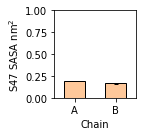

In [5]:
# plot
df = pd.read_csv('avg_SC_SASA_SER47.csv')
df.plot(x='Chain',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.ylabel('S47 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SER47_SASA_barplot.pdf')

In [6]:
chains = ['A','B']
colors = ['blue','red','orange']
nsims=3

avg = []
err = []

for i in range(len(chains)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        dat = np.loadtxt(path+"sim{}/sasa_chain{}_TYR67.xvg".format(s,chains[i]),skiprows=25)
    
        sasa = dat[:,2]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        vals.append(np.mean(sasa)) 

    avg.append(np.mean(vals))
    err.append(np.std(vals)/np.sqrt(nsims))
    
df = pd.DataFrame()
df['Chain'] = chains
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err

df.to_csv('avg_SC_SASA_TYR67.csv')
df

,Chain,SASA (nm$^{2}$),Error
0,A,0.071698,0.001730
1,B,0.065646,0.000455


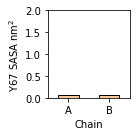

In [7]:
# plot
df = pd.read_csv('avg_SC_SASA_TYR67.csv')
df.plot(x='Chain',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,2)

plt.ylabel('Y67 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('TYR67_SASA_barplot.pdf')